# Compulsory Assignment 1: Dense neural networks - Implementing an ANN with Keras

Please fill out the the group name, number, members and optionally the group name below. 

**Group number**: 2 \
**Group member 1**: Kristian Mathias Røhne\
**Group member 2**: Simen Roko Krogstie\
**Group member 3**: Erling Hamil Mysen\
**Group name (optional)**: The Three Musketeers

# Assignment submission

To complete this assignment, answer the all the questions in this notebook and write the code required to implement different models. **Submit the assignment by handing in this notebook as both an .ipynb file and a .pdf file**.

Here are some do’s and don’ts for the submission:

- Read questions thoroughly before answering.
- Make sure to answer all questions.
- Ensure all code cells are run.
- Label all axes in plots.
- Ensure all figures are visible in the PDF.

# Introduction 

In this assignment we will continue with the task of classifying handwritten digits from the MNIST dataset, used in the voluntary assignment where we designed a neural network from scratch. But, today you will implement the network using the Keras API of the TensorFlow library. TensorFlow and PyTorch are both free open-source software libraries intended to simplify multiplication of tensors, but are mostly used for the design and implementation of deep neural networks. Both libraries simplify the implementation of neural networks, and allow for faster training of networks by utlizing hardware acceleration with Graphical Processing Units (GPUs) or Tensor Processing Units (TPUs)

TensorFlow was developed by Google Brain for internal use in Google and was initially released under Apache 2.0 License in 2015 [1](https://en.wikipedia.org/wiki/TensorFlow). Keras was initially released as separate software library, developed by François Chollet, to simplify the Python interface for design of artificial neural networks. Up until version 2.3 Keras supported multiple backend libraries including TensorFlow, Microsoft Cognitive Toolkit, Theano, and PlaidML [2](https://en.wikipedia.org/wiki/Keras). When TensorFlow 2.0 was released in 2019, keras was included as a TensorFlow specific API that is accessible by:

```python
import tensorflow.keras as ks
```
PyTorch was originally developed by Meta AI (formerly known as Facebook) in 2016, but is now under umbrella of the Linux foundation, and is open-source under the BSD license [3](https://en.wikipedia.org/wiki/PyTorch). While TensorFlow was the most popular framework for a long time, PyTorch has been gaining more and more users in the last five years and is now more used in industry and is becoming more popular in research as well. 

The lectures of DAT300 will be taught using the Keras API in TensorFlow, and we recommend you to stick with Keras and TensorFlow for this course as it is easier for beginners to get started with. 

## Assignment structure

1. Part 1: Import, preprocess, and visualize the data.
2. Part 2: Use the Keras API to implement a Dense Neural Network (NN) that resembles the model given in the voluntary assignment.
3. Part 3: Design your own Dense Neural Network (NN) architecture for classifying MNIST in Keras.
4. Part 4: Train a Machine Learning classifier that you learned about in DAT200.
5. Part 5: Compare and discuss the results.

## Note on the voluntary assignment

Some of the questions in this task will ask you to compare the results from training this network to the results you had in the voluntary assignment with regard to training algorithm used and the time it took to train the network implemented with Numpy and with TensorFlow/PyTorch. If you did not do the voluntary assignment yourself, have a look at the solutions that should be posted and run through the solutions-notebook to get the results you need for a comparison.


## Library imports

In [3]:
import time
from tqdm import tqdm # Cool progress bar

import numpy as np
import pandas as pd
import tensorflow.keras as ks
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from utilities import *

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import Accuracy

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

import time


SEED = 458
RNG = np.random.default_rng(SEED) # Random number generator

# Task 1: Importing, preprocess and visualizing the data
To import the data of the MNIST dataset for this assignment
* Copy the data/ folder from the folder where you kept the last assignment, and run the load_data() function from the `utilities.py` file.
* Just download the data again by re-running the load_data() function from the `utilities.py` file.

In this assignment you yourselves will be responsible for the data-preprocessing. Use the cells below for preprocessing and visualization, and optionally some exploration of the dataset if you feel inclined. 

## Importing data

In [5]:
datasets = load_mnist(verbose=0)
X_train, y_train = datasets['X_train'], datasets['y_train']
X_val,   y_val   = datasets['X_val'],   datasets['y_val']
X_test,  y_test  = datasets['X_test'],  datasets['y_test']

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0).astype('int32')

del datasets, X_val, y_val # Good to reduce uneccesary RAM usage

## Task 1.1 Preprocessing
Preprocess the data in whatever way you find sensible. Remember to comment on what you do.

In [6]:
# Normalizing datasets between [0,1]

# Normalizing X_train and X_test beween 0 and 1 to achieve convergence faster during training. 
X_train = X_train.astype("float32")/np.max(X_train)
X_test = X_test.astype("float32")/np.max(X_test)

In [7]:
# One-hot encoding the labels to categorical data.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## Task 1.2 Visualization
Visualize the data in whatever manner you find helpful/sensible and briefly comment on the plots.

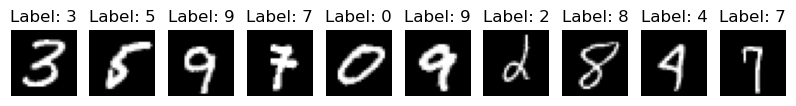

In [8]:
# Assuming you have the train_images and train_labels loaded
def plot_sample_images(images, labels, num_samples=10):
    plt.figure(figsize=(10, 2))
    
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    
    plt.show()

# Plot 10 sample images
plot_sample_images(X_train, y_train.argmax(axis=1), num_samples=10)

# Task 2: TensorFlow vs. Numpy
In this task you will redesign the network you implemented in Numpy (from the voluntary assignment) using TensorFlow, and then compare the two implementations.
## Task 2.1: Implement the F1-score
In the cell below, implement or import a function for the F1-score metric.

In [9]:
def f1_score_metric(y_true, y_pred):
    # Convert predicted probabilities to binary predictions for each class (multi-label).
    y_pred = tf.round(y_pred)

    # Calculate precision for each class.
    precision = tf.reduce_sum(tf.cast(y_true * y_pred, 'float'), axis=0) / (tf.reduce_sum(tf.cast(y_pred, 'float'), axis=0) + tf.keras.backend.epsilon())

    # Calculate recall for each class. 
    recall = tf.reduce_sum(tf.cast(y_true * y_pred, 'float'), axis=0) / (tf.reduce_sum(tf.cast(y_true, 'float'), axis=0) + tf.keras.backend.epsilon())

    # Calculate F1 score for each class.
    f1 = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
    
    # Return mean F1 score across all classes
    return tf.reduce_mean(f1)  

## Task 2.2: Implement the network from the voluntary assignment
Implement a network with the following architecture:
* Input layer: (28, 28)
* Hidden layer: 30 units, sigmoid activation
* Output layer: 10 units, sigmoid activation

Compile the model using:
* The `'MSE'` loss function
* The `SGD` optimizer with `learning_rate=0.25`
* both `'accuracy'` and the implementation of the **F1-score** from Task 2.1 as metrics

Train the model using:
* batch size of 10 images
* 5 epochs
* A validation split of 1/6

Implement the model in the code cell(s) below.

In [10]:
# Build the model
model = Sequential([
    Flatten(input_shape=(28, 28)),    # Flatten input layer from a 2D to 1D vector, so it fits the Dense layers. 
    Dense(30, activation='sigmoid'),  # First hidden Dense layer with 30 units, sigmoid activation function.
    Dense(10, activation='sigmoid')   # Output Dense layer with 10 units, sigmoid activation function. 
])



# Compile the model
model.compile(
    loss='mean_squared_error',           # Using MSE as loss function. 
    optimizer=SGD(learning_rate=0.25),   # SGD optimizer with learning rate of 0.25.
    metrics=['accuracy', f1_score_metric]  # Accuracy to get percentage of correct preds and custom F1 score.
)

/opt/anaconda3/envs/DAT300/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Task 2.3: Train the network and plot the training history
Train the model and plot the training history in the code cell(s) below. Use the same method for plotting the training process as in the voluntary assignment. Feel free to use the function `plot_training_history()` from `utilities.py`

In [11]:
# Start time for Model 1. 
start_time = time.time()

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=10,             # Setting batch size to 10.
    epochs=5,                  # Setting the model to train over 5 epochs.
    validation_split=1/6       # Utilizing 1/6 of the training data for validation.
)

# End time for Model 1
end_time = time.time()

# Calculating total training time of the model.
model1_training_time = end_time - start_time    


Epoch 1/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 3s 470us/step - accuracy: 0.4752 - f1_score_metric: 0.0804 - loss: 0.0778 - val_accuracy: 0.8380 - val_f1_score_metric: 0.3868 - val_loss: 0.0379
Epoch 2/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 443us/step - accuracy: 0.8521 - f1_score_metric: 0.4289 - loss: 0.0338 - val_accuracy: 0.8870 - val_f1_score_metric: 0.5233 - val_loss: 0.0248
Epoch 3/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 434us/step - accuracy: 0.8844 - f1_score_metric: 0.5217 - loss: 0.0236 - val_accuracy: 0.8974 - val_f1_score_metric: 0.5435 - val_loss: 0.0205
Epoch 4/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 437us/step - accuracy: 0.8948 - f1_score_metric: 0.5453 - loss: 0.0202 - val_accuracy: 0.9041 - val_f1_score_metric: 0.5593 - val_loss: 0.0182
Epoch 5/5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 436us/step - accuracy: 0.9054 - f1_score_metric: 0.5534 - loss: 0.0179 - val_accuracy: 0.9089 - val_f1_score_metric: 0.5678 - val_loss: 0.0168


In [12]:
# Printing the total training time of model 1
print(f'{model1_training_time:.5f} seconds')

11.46076 seconds


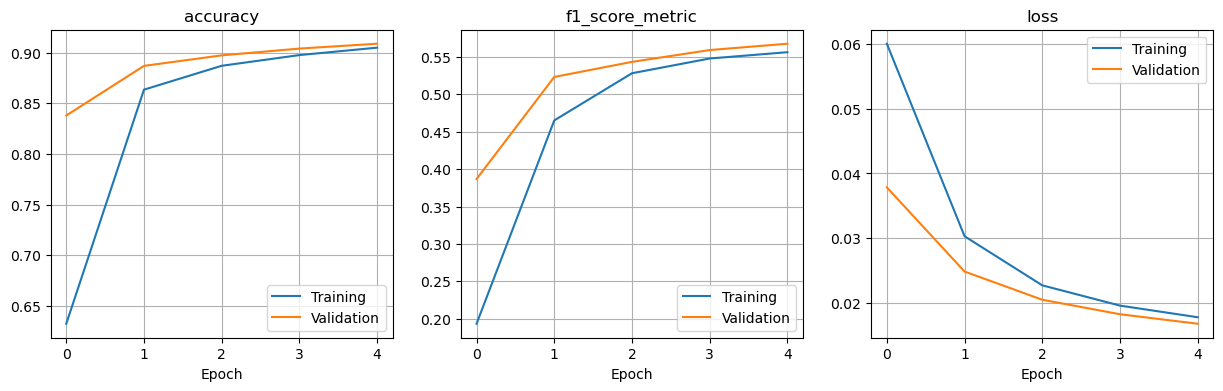

In [13]:
# Plotting training history
plot_training_history(history)

## Task 2.4: Compare the results from the TensorFlow implementation with the Numpy implementation
**Question 2.4.1**: How long did it take to train the TensorFlow implementation of the network on the *entire* dataset for five epochs compared to the time it took to train the Numpy implementation?

**Question 2.4.2**: What is the biggest (defining) difference in how the TensorFlow implementation **was trained** compared to the Numpy implementation?

**Question 2.4.3**: Were there any significant differences in the ease of implementation and the amount of code needed for the TensorFlow and Numpy implementations?

**Answer 2.4.1**: \
Training the TensorFlow implementation took 16.73 seconds, while training the Numpy implementation took 135 seconds. So the TensorFlow implementation was way faster when training the whole dataset.

**Answer 2.4.2**: \
The biggest differene between the TensorFlow and Numpy implementation training was that in the Numpy implementation, the loss function is computed manually (evalute_loss). However, in the TensorFlow implementation, we used the pre-buildt Keras function mean_squared_error as loss the function. In the custom implementation, the forward pass seems to be done on the entire dataset at once. Keras allows for easy mini-batch processing, which is important for handling large datasets and making training more efficient.

**Answer 2.4.3**: \
In the numpy implementation, you have to make your own functions for forward and backpropagation. You also have to maually implement your own optimizers, unlike with Keras, where different optimizers are easly available. Accuracy had to be implemented manually.

# Task 3: Design your own ANN architecture
As you probably noticed in the last task, the performance of the simple network with a single hidden layer and 30 hidden units does not perform particularily well. In this task you are free to design the network architecture for the MNIST handwritten digit recognition challenge with a couple of stipulations:
* use **only Dense or fully connected layers**,
* use both **accuracy and the F1-score** as performance metrics. 

Otherwise, you are free to use whatever loss-function, optimizer and activation functions you want and train it for as many epochs you want.

## Task 3.1: Implement your own network architecture
Design your network below:

(Feel free to add as many code and markdown cells as you want)

In [15]:
# Build the model
model2 = Sequential([
    Flatten(input_shape=(28, 28)),      # Flatten input layer from 2D to 1D vector sot it fits the Dense layer.
    Dense(60, activation='tanh'),       # Hidden layer with 30 units, tanh activation function
    Dense(30, activation='tanh'),       # Hidden layer with 30 units, tanh activation function
    Dense(10, activation='softmax')     # Output layer with 10 units, softmax activation
])

# Compile the model
model2.compile(
    loss='mean_squared_error',           # Using MSE as loss
    optimizer=SGD(learning_rate=0.25),   # SGD optimizer with learning rate of 0.25
    metrics=['accuracy', f1_score_metric]  # # Accuracy to get percentage of correct preds and custom F1 score.
)

## Task 3.2: Train your network and visualize the training history
Train the model and plot the training history in the code cell(s) below. Use the same method for plotting the training process as in the voluntary assignment. Feel free to use the function `plot_training_history()` from `utilities.py`

In [16]:
# Start time for model 2
start_time = time.time()

# Train the model
history2 = model2.fit(
    X_train, y_train,          # Training data 
    batch_size=10,             # Setting batch size to 10
    epochs=10,                 # Setting the model to train over 5 epochs
    validation_split=1/6       # Utilizing 1/6 of the training data for validation.
)

# End time for Model 2
end_time = time.time()

# Calculating total training time for the model.
model2_training_time = end_time - start_time

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 3s 542us/step - accuracy: 0.7786 - f1_score_metric: 0.4067 - loss: 0.0336 - val_accuracy: 0.9229 - val_f1_score_metric: 0.5916 - val_loss: 0.0121
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 3s 510us/step - accuracy: 0.9275 - f1_score_metric: 0.5921 - loss: 0.0115 - val_accuracy: 0.9347 - val_f1_score_metric: 0.6024 - val_loss: 0.0100
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 484us/step - accuracy: 0.9433 - f1_score_metric: 0.6047 - loss: 0.0090 - val_accuracy: 0.9460 - val_f1_score_metric: 0.6129 - val_loss: 0.0084
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 484us/step - accuracy: 0.9540 - f1_score_metric: 0.6102 - loss: 0.0073 - val_accuracy: 0.9514 - val_f1_score_metric: 0.6168 - val_loss: 0.0076
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 493us/step - accuracy: 0.9598 - f1_score_metric: 0.6191 - loss: 0.0065 - val_accuracy: 0.9539 - val_f1_score_metric: 0.6186 - val_loss: 0.0069
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 2s 488us/step - ac

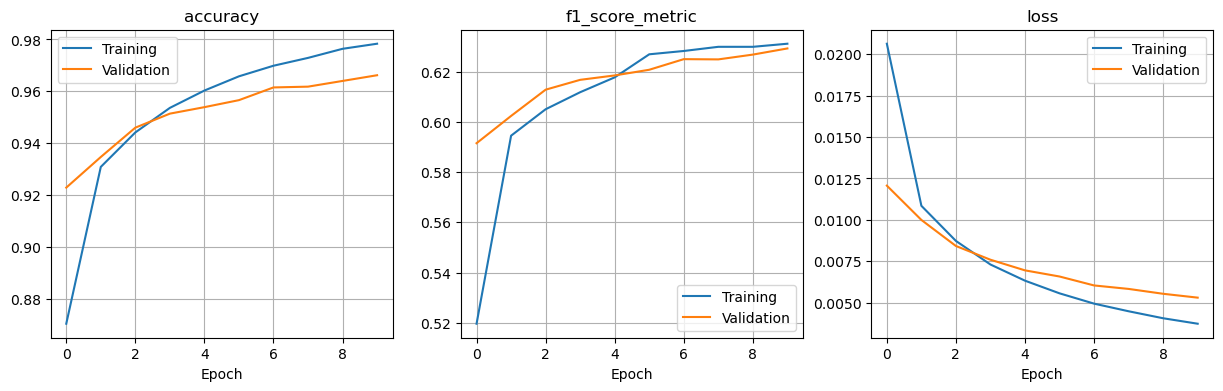

In [17]:
# Plotting training history.
plot_training_history(history2)

## Task 3.3: Discuss the results
**Question 3.3.1**: Compare the performance of your new model with the model from Task 2. Did the new model achieve higher accuracy and F1-score? What could be the reasons for that?

**Question 3.3.2**: Did overfitting occur? If so, after how many epochs? Does overfitting typically increase or decrease with the increasing model complexity?

**Question 3.3.3**: How do accuracy and F1-Score values compare (are they similar or very different from each other)? What does it tell you about the MNIST dataset and which one of these metrics is more reliable in this case?

**Question 3.3.4**: Explain **very briefly** how each of the following model hyperparameters can impact the model's performance:
- Number of layers
- Number of neurons in a layer
- Activation functions
- Learning rate.
- Regularization techniques (such as L2 regularization).

**Answer 3.3.1**: \
For the first model: Test Accuracy: 0.9115999937057495, Test F1 Score: 0.8584654331207275 \
For the second model: Test Accuracy: 0.9668999910354614, Test F1 Score: 0.9360830187797546 \
The last model achived a higher accuracy and F1 score. That is we added another hidden layer with 60 units, used the tanh acitvation function in the hidden layers and softmax at the output layer. 


**Answer 3.3.2**: \
It looks like the second model started to overfit after the third epoch, since the training accuracy was better than the validation accuracy. However, the model improved on both metrics. Overfitting typically increase with model complexity since the model will be better at learning the training data, and not generalize to unseen data. 

**Answer 3.3.3**: \
The accuracy was higher than the F1-score, but they are not very different from eachother. This tells us that the MNIST dataset has a balanced distribution of digits, but it struggles with certain classes. Since the MNIST dataset is quite balanced, accuracy is more reliable.

**Answer 3.3.4**: \
More layers allow the model to learn more complex patterns, but can also increase the risk of overfitting and increase training time. 

More neurons in a layer can capture more features and complexity, but too many can lead to overfitting, inefficient computation and increase training time. 

The choice of activation function affects how non-linear patterns are learned, impacting both training speed and the models accuracy. 

A higher learning rate speeds up the updating of weights, but can overshoot the optimal solution. A lower learning rate can slow down training or worst case cause the model to get stuck, but may find a better solution. 

Regularization techniques can help to prevent overfitting by penalizing large weights, couraging the model to generalize better to unseen data. 

# Task 4: Design and train a _classical_ machine learning classifier
Pick your **favourite** machine learning classifer that you learned about in DAT200 and train it for the MNIST handwritten digits recognition problem. (Hint: use the scikit-learn library). Remember to use **accuracy and the F1-score** as performance metrics.

In [16]:
# Flatten training data from 2D image to (samples, height * width)/1D array
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Flatten test data from 2D image to (samples, height * width)/1D array
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Start time for model 3
start_time = time.time()
# Initializing Random forest model with 100 decision trees.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the Random forest model
rf_model.fit(X_train_flat, y_train)

# End time for model 3
end_time = time.time()

# Calculating total training time for model 3
rf_model_training_time = end_time - start_time

# Task 5: Compare and discuss
Evaluate the four models you have implemented in task 2, 3 and 4 on the test dataset and compare them based on
* Accuracies and F1-scores they attain
* Time it takes to train them

Did you experience any trouble when training models in tasks 2-4?

In [17]:
# Evaluating mode 1 on test data.
test_loss, test_accuracy, test_f1 = model.evaluate(X_test, y_test)
print(f'Model 1 - Accuracy: {test_accuracy}, F1 Score: {test_f1}, Training Time: {model1_training_time} seconds')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - accuracy: 0.8992 - f1_score_metric: 0.8423 - loss: 0.0184
Model 1 - Accuracy: 0.9132999777793884, F1 Score: 0.8622542023658752, Training Time: 11.398140907287598 seconds


In [18]:
# Evaluate model 2 on test data.
test_loss, test_accuracy, test_f1 = model2.evaluate(X_test, y_test)
print(f'Model 2 - Accuracy: {test_accuracy}, F1 Score: {test_f1}, Training Time: {model2_training_time} seconds')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step - accuracy: 0.9636 - f1_score_metric: 0.9264 - loss: 0.0058
Model 2 - Accuracy: 0.9674000144004822, F1 Score: 0.9368376731872559, Training Time: 27.675676822662354 seconds


In [19]:
# Evaluating model 3 on test data.
y_pred = rf_model.predict(X_test_flat)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Model 3 - Accuracy: {accuracy * 100:.2f}%, F1 Score: {f1:.2f}, Training Time: {rf_model_training_time} seconds')

Model 3 - Accuracy: 90.14%, F1 Score: 0.94, Training Time: 41.90174412727356 seconds


**Task 5 discussion Here:**


The custom ANN had the best accuracy, but the Random Forest had the best F1-score. That is, the custom ANN may have focused more on getting the majority of predictions correct, but struggeled with harder samples or classes, lowering its F1-score. 

The first ANN was the fastest to train, since it has less layers, units and epochs, while the Random Forest was slowest. That may be beacause of many decision trees in the Random Forest, lack of GPU acceleration since it relies on CPU processing, and that working with flattened images with many features increased the training time for each tree. 

When we were training the random forest classifier first we struggled a little, but we sorted it out after flattening out the training data. Otherwise, everything else went fine. 